In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset (Fashion-MNIST)
# -----------------------------
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# Flatten images for baseline model
x_train_full = x_train_full.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# -----------------------------
# Split into train/val/test
# -----------------------------
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

# -----------------------------
# Baseline Model
# -----------------------------
baseline_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=64
)

# Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(x_test, y_test)
print("Baseline Test Accuracy:", baseline_test_acc)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8115 - loss: 0.5410 - val_accuracy: 0.8545 - val_loss: 0.4181
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8561 - loss: 0.4023 - val_accuracy: 0.8583 - val_loss: 0.3887
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8695 - loss: 0.3616 - val_accuracy: 0.8768 - val_loss: 0.3524
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8783 - loss: 0.3330 - val_accuracy: 0.8817 - val_loss: 0.3340
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8843 - loss: 0.3168 - val_accuracy: 0.8832 - val_loss: 0.3280
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8899 - loss: 0.3003 - val_accuracy: 0.8716 - val_loss: 0.3660
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reshape back to 28x28x1 for augmentation
x_train_img = x_train.reshape(-1, 28, 28, 1)
x_val_img = x_val.reshape(-1, 28, 28, 1)
x_test_img = x_test.reshape(-1, 28, 28, 1)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train_img)

improved_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),

    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_improved = improved_model.fit(
    datagen.flow(x_train_img, y_train, batch_size=64),
    validation_data=(x_val_img, y_val),
    epochs=30,
    callbacks=[early_stop]
)

# Evaluate on test set
improved_test_loss, improved_test_acc = improved_model.evaluate(x_test_img, y_test)
print("Improved Test Accuracy:", improved_test_acc)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.6372 - loss: 1.4326 - val_accuracy: 0.7602 - val_loss: 0.9897
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.6907 - loss: 1.1057 - val_accuracy: 0.7617 - val_loss: 0.8548
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.6979 - loss: 0.9952 - val_accuracy: 0.7576 - val_loss: 0.8058
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.6990 - loss: 0.9465 - val_accuracy: 0.7628 - val_loss: 0.7489
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.7034 - loss: 0.9176 - val_accuracy: 0.7770 - val_loss: 0.7146
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7031 - loss: 0.8992 - val_accuracy: 0.7417 - val_loss: 0.7412
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7058 - loss: 0.8857 - val_accuracy: 0.7830 - val_loss: 0.6799
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.7074 - loss: 0.8748 - 

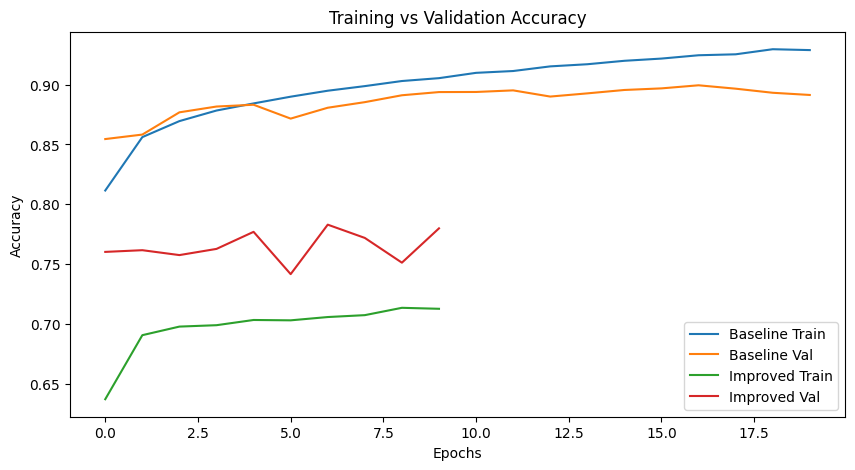

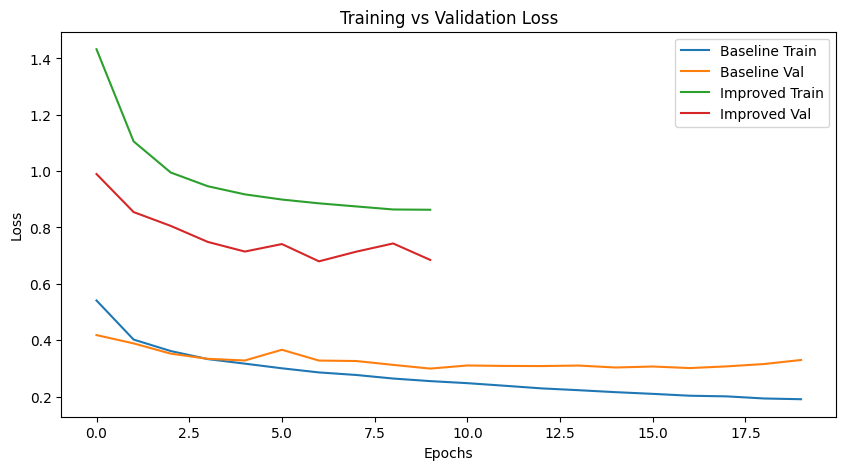

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history_baseline.history['accuracy'], label='Baseline Train')
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Val')
plt.plot(history_improved.history['accuracy'], label='Improved Train')
plt.plot(history_improved.history['val_accuracy'], label='Improved Val')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history_baseline.history['loss'], label='Baseline Train')
plt.plot(history_baseline.history['val_loss'], label='Baseline Val')
plt.plot(history_improved.history['loss'], label='Improved Train')
plt.plot(history_improved.history['val_loss'], label='Improved Val')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()